# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write Rust quantized samples in `audio_samples/<model>.rs`.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import tensorflow as tf

from utils import (
    TARGET_AUDIO_LEN_TIME,
    SAMPLE_RATE,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "sincnet_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32


In [23]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [ ]:
from model_parts import SincnetConv
from utils import get_flops_native

In [25]:
SINCNET_FILTERS = 96
SINCNET_STRIDE = 16
SINCNET_KERNEL_SIZE = 64

CONV_FILTERS = 16
CONV_FILTER_SIZE = 5
CONV_STRIDE = 1

DENSE_HIDDEN = 64


def build_training_model(num_labels: int) -> tf.keras.Model:
    # NHWC: time = height, fixed width 1 — matches microflow rank-4 buffers.
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))

    # Use the real SincNet!
    x = SincnetConv(
        num_filters=SINCNET_FILTERS,
        kernel_size=SINCNET_KERNEL_SIZE,
        stride=SINCNET_STRIDE,
        sample_rate=SAMPLE_RATE,
        name="sincnet_convolution",
    )(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(5, 1), name="envelope_pool")(x)

    x = tf.keras.layers.Conv2D(
        filters=CONV_FILTERS,
        kernel_size=(CONV_FILTER_SIZE, 1),
        strides=(CONV_STRIDE, 1),
        padding="same",
        name="temporal_conv_2",
    )(x)
    x = tf.keras.layers.ReLU()(x)

    # GlobalAveragePooling1D maps to MEAN in TFLite which microflow doesn't support.
    # AveragePooling2D maps to AVERAGE_POOL_2D — pool the full time (height) axis.
    x = tf.keras.layers.AveragePooling2D(
        pool_size=(x.shape[1], 1), padding="valid", name="avg_pool"
    )(x)
    x = tf.keras.layers.Flatten(name="flatten")(x)

    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)

    return tf.keras.Model(inputs, outputs, name="sincnet_training")

training_model = build_training_model(num_labels)
training_model.summary()

flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 47872, 1, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sincnet_convolution             │ (None, 2988, 1, 96)    │           192 │
│ (SincnetConv)                   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 2988, 1, 96)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ envelope_pool                   │ (None, 597, 1, 96)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv2D)        │ (None, 597, 1, 16)     │         7,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 597, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool (AveragePooling2D)     │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,106 (35.57 KB)

 Trainable params: 9,106 (35.57 KB)

 Non-trainable params: 0 (0.00 B)

/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_40
Received: inputs=['Tensor(shape=(1, 47872, 1, 1))']
  warnings.warn(msg)


Total FLOPs: 46818854


2026-04-30 15:33:13.863930: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-30 15:33:13.864908: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-30 15:33:13.864969: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-30 15:33:13.865554: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-30 15:33:13.866422: I external/local_xla/xla/stream_executor/cuda/cuda_e

In [26]:
from utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb(MODEL_STEM, config={
    "sincnet_num_filters": SINCNET_FILTERS,
    "sincnet_kernel_size": SINCNET_KERNEL_SIZE,
    "sincnet_stride": SINCNET_STRIDE,
    "conv_filters": CONV_FILTERS,
    "conv_filter_size": CONV_FILTER_SIZE,
    "conv_stride": CONV_STRIDE,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8210 - loss: 0.3627 - val_accuracy: 0.9341 - val_loss: 0.1952


batch/accuracy,▁▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███████
batch/batch_step,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,████▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁
epoch/epoch,▁
epoch/learning_rate,▁
epoch/loss,▁
epoch/val_accuracy,▁
epoch/val_loss,▁
+6,...


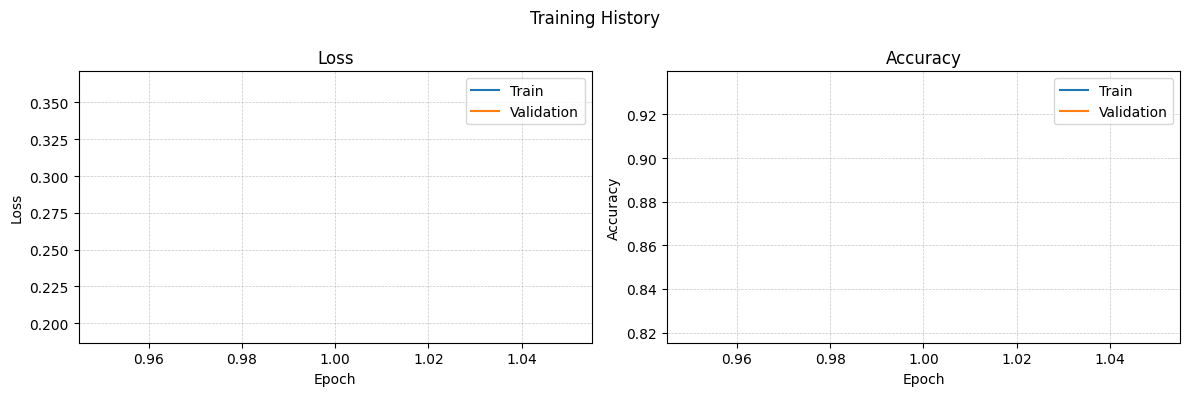

In [27]:
from utils import plot_training_history
plot_training_history(history)

## Make frontend filters into a Conv2D inference model


In [28]:
frontend_layer = training_model.get_layer("sincnet_convolution")
baked_conv_layer = frontend_layer.export_to_conv2d(name="baked_sinc_conv")


def to_conv2d_ready_input(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x)
    if arr.ndim == 3:
        return arr[..., np.newaxis]
    if arr.ndim in (2, 4):
        return arr
    raise ValueError(f"Unsupported rank {arr.ndim}; expected 2, 3, or 4")


infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))
x = baked_conv_layer(infer_inputs)
for layer in training_model.layers:
    if isinstance(layer, (tf.keras.layers.InputLayer, type(frontend_layer))):
        continue
    x = layer(x)

inference_model = tf.keras.Model(infer_inputs, x, name="sincnet_inference")

for batch_audio, _ in test_ds.take(1):
    batch_np = batch_audio.numpy()
    batch_conv2d = to_conv2d_ready_input(batch_np)
    logits_train = training_model.predict(batch_conv2d, verbose=0)
    logits_infer = inference_model.predict(batch_conv2d, verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000000


2026-04-30 15:33:42.507833: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [29]:
rep_batches = build_representative_batches(test_ds, take=100)
rep_batches = [to_conv2d_ready_input(batch) for batch in rep_batches]

try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

Saved artifact at '/tmp/tmpph2vuawy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 47872, 1, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  128338924463984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128337851511056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128337851505600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128337851506128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128337851505424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128337851506480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128337851505072: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-04-30 15:33:42.796862: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
W0000 00:00:1777556022.958250   11945 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1777556022.958263   11945 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-30 15:33:42.958380: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpph2vuawy
2026-04-30 15:33:42.958682: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-30 15:33:42.958690: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpph2vuawy
2026-04-30 15:33:42.962751: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-30 15:33:42.979816: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /tmp/tmpph2vuawy
2026-04-30 15:33:42.985177: I tensorflow/cc/s

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_real_tf.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-04-30 15:33:43.425872: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3064] Estimated count of arithmetic ops: 47.055 M  ops, equivalently 23.528 M  MACs


In [ ]:
from utils import evaluate_tflite_model

hyperparams = {
    "sincnet_filters": SINCNET_FILTERS,
    "sincnet_kernel_size": SINCNET_KERNEL_SIZE,
    "sincnet_stride": SINCNET_STRIDE,
    "conv_filters": CONV_FILTERS,
    "conv_filter_size": CONV_FILTER_SIZE,
    "conv_stride": CONV_STRIDE,
    "dense_hidden": DENSE_HIDDEN,
    "target_audio_len": TARGET_AUDIO_LEN_TIME,
    "sample_rate": SAMPLE_RATE,
    "batch_size": BATCH_SIZE,
}

train_m, test_m, avg_ms = evaluate_tflite_model(
    OUT_TFLITE, MODEL_STEM, train_ds, test_ds, hyperparams=hyperparams,
)
print(f"Avg inference: {avg_ms:.3f} ms")